In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Load data
df = pd.read_csv('../data/synthetic/kavach_synthetic.csv')

print("Dataset loaded:", df.shape)
print("\nFirst 3 rows:")
df.head(3)

Dataset loaded: (10000, 16)

First 3 rows:


,timestamp,train_id,section_id,section_speed_limit,speed_kmh,signal_aspect,rfid_read_success,radio_packet_loss_pct,weather_index,freight_load_tonnes,deceleration_rate,section_incident_rate,movement_authority_m,advisory_speed_kmh,is_anomaly,anomaly_type
0,2024-01-01 20:18:31,TRAIN-07,SEC-05,120,86.2,yellow,1,4.91,0.187,2802.3,0.658,0.03,240.5,75.2,0,none
1,2024-01-01 16:37:48,TRAIN-06,SEC-04,90,76.7,green,1,38.82,0.036,1102.3,0.434,0.08,355.7,73.3,1,radio_drop
2,2024-01-01 13:56:51,TRAIN-04,SEC-04,90,80.2,green,1,4.34,0.101,1212.8,0.691,0.08,366.7,75.4,0,none


In [3]:
# Convert signal_aspect text to numbers
# green=2, yellow=1, red=0
le = LabelEncoder()
df['signal_encoded'] = le.fit_transform(df['signal_aspect'])

# Input features (X) - what the model sees
X = df[['speed_kmh', 'signal_encoded', 'weather_index', 
        'freight_load_tonnes', 'section_speed_limit',
        'section_incident_rate', 'rfid_read_success',
        'radio_packet_loss_pct', 'deceleration_rate']]

# Target (y) - what the model learns to predict
y = df['movement_authority_m']

print("Input features shape:", X.shape)
print("Target shape:", y.shape)
print("\nFeature columns:", list(X.columns))
print("\nTarget range:")
print(f"  Min MA: {y.min():.1f} metres")
print(f"  Max MA: {y.max():.1f} metres")
print(f"  Avg MA: {y.mean():.1f} metres")

Input features shape: (10000, 9)
Target shape: (10000,)

Feature columns: ['speed_kmh', 'signal_encoded', 'weather_index', 'freight_load_tonnes', 'section_speed_limit', 'section_incident_rate', 'rfid_read_success', 'radio_packet_loss_pct', 'deceleration_rate']

Target range:
  Min MA: 50.0 metres
  Max MA: 1793.5 metres
  Avg MA: 237.7 metres


In [4]:
# Split: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training set:  ", X_train.shape)
print("Testing set:   ", X_test.shape)
print(f"\nThe model will train on {len(X_train)} rows")
print(f"and be tested on {len(X_test)} rows it has never seen before")

Training set:   (8000, 9)
Testing set:    (2000, 9)

The model will train on 8000 rows
and be tested on 2000 rows it has never seen before


In [5]:
from xgboost import XGBRegressor

# Create the model
model = XGBRegressor(
    n_estimators=200,      # 200 decision trees
    max_depth=6,           # how deep each tree goes
    learning_rate=0.1,     # how fast it learns
    random_state=42
)

# Train it!
print("Training the MA model...")
model.fit(X_train, y_train)
print("Training complete!")

# Make predictions on test set
y_pred = model.predict(X_test)
print(f"\nFirst 5 predictions vs actual:")
for i in range(5):
    print(f"  Predicted: {y_pred[i]:.1f}m  |  Actual: {y_test.iloc[i]:.1f}m")
    

Training the MA model...
Training complete!

First 5 predictions vs actual:
  Predicted: 521.1m  |  Actual: 526.5m
  Predicted: 53.5m  |  Actual: 50.0m
  Predicted: 70.4m  |  Actual: 96.9m
  Predicted: 250.6m  |  Actual: 279.1m
  Predicted: 512.0m  |  Actual: 523.2m


In [6]:
# Calculate accuracy metrics
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae  = mean_absolute_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)

print("=" * 40)
print("   MA MODEL EVALUATION RESULTS")
print("=" * 40)
print(f"   RMSE : {rmse:.2f} metres")
print(f"   MAE  : {mae:.2f} metres")
print(f"   R²   : {r2:.4f}")
print("=" * 40)

if rmse < 50:
    print("   TARGET MET! RMSE is under 50m")
else:
    print("   RMSE above 50m - we can improve this")

print("\nWhat these mean:")
print(f"  - On average the model is off by {mae:.1f} metres")
print(f"  - R² of {r2:.4f} means the model explains")
print(f"    {r2*100:.1f}% of the variation in MA distance")

   MA MODEL EVALUATION RESULTS
   RMSE : 19.05 metres
   MAE  : 12.00 metres
   R²   : 0.9900
   TARGET MET! RMSE is under 50m

What these mean:
  - On average the model is off by 12.0 metres
  - R² of 0.9900 means the model explains
    99.0% of the variation in MA distance


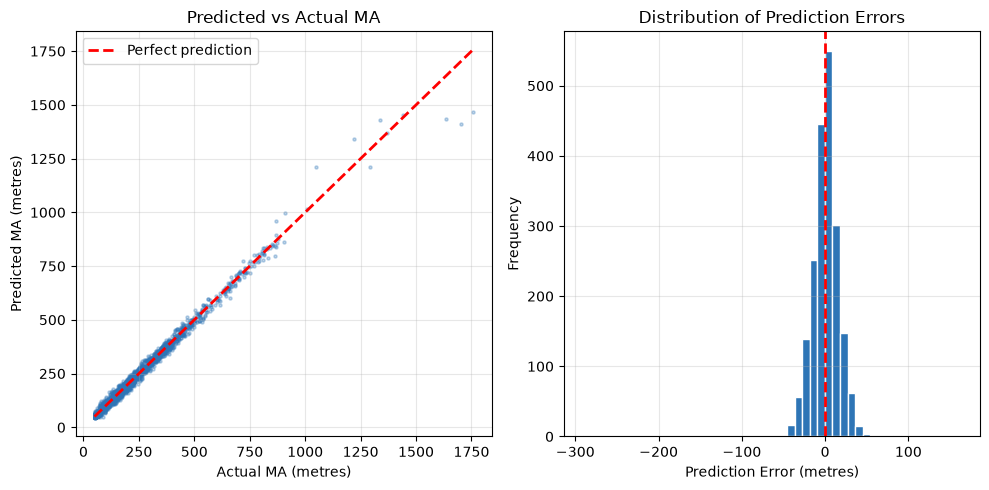

Errors centered around: 0.22m
Most errors fall between: -8.5m and 9.9m


In [7]:
plt.figure(figsize=(10, 5))

# Plot 1 - Predicted vs Actual
plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred, alpha=0.3, s=5, color='#2E75B6')
plt.plot([y_test.min(), y_test.max()], 
         [y_test.min(), y_test.max()], 
         'r--', linewidth=2, label='Perfect prediction')
plt.xlabel('Actual MA (metres)')
plt.ylabel('Predicted MA (metres)')
plt.title('Predicted vs Actual MA')
plt.legend()
plt.grid(alpha=0.3)

# Plot 2 - Error distribution
plt.subplot(1, 2, 2)
errors = y_pred - y_test
plt.hist(errors, bins=50, color='#2E75B6', edgecolor='white')
plt.axvline(x=0, color='red', linestyle='--', linewidth=2)
plt.xlabel('Prediction Error (metres)')
plt.ylabel('Frequency')
plt.title('Distribution of Prediction Errors')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Errors centered around: {errors.mean():.2f}m")
print(f"Most errors fall between: {errors.quantile(0.25):.1f}m and {errors.quantile(0.75):.1f}m")

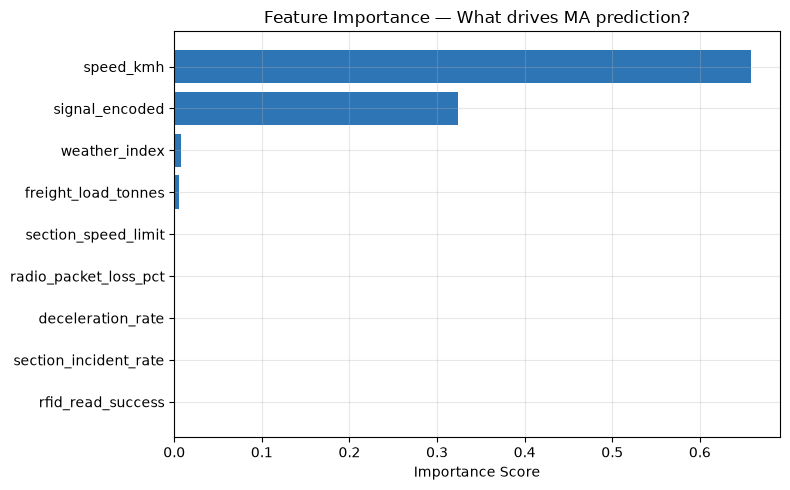


Top 3 most important features:
  speed_kmh: 0.6585
  signal_encoded: 0.3245
  weather_index: 0.0076


In [8]:
# Which features does the model rely on most?
importance = pd.DataFrame({
    'feature': X.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(importance['feature'], importance['importance'], color='#2E75B6')
plt.title('Feature Importance — What drives MA prediction?')
plt.xlabel('Importance Score')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("\nTop 3 most important features:")
top3 = importance.sort_values('importance', ascending=False).head(3)
for i, row in top3.iterrows():
    print(f"  {row['feature']}: {row['importance']:.4f}")

In [9]:
import joblib
import os

# Create save directory if it doesn't exist
os.makedirs('../models/saved', exist_ok=True)

# Save the model
joblib.dump(model, '../models/saved/ma_model.pkl')

# Save the label encoder too (we'll need it later)
joblib.dump(le, '../models/saved/ma_label_encoder.pkl')

print("✅ Model saved to: models/saved/ma_model.pkl")
print("✅ Encoder saved to: models/saved/ma_label_encoder.pkl")

# Verify by reloading and making one prediction
loaded_model = joblib.load('../models/saved/ma_model.pkl')
test_input = X_test.iloc[0:1]
test_pred = loaded_model.predict(test_input)
print(f"\nVerification — model reloaded successfully!")
print(f"Test prediction: {test_pred[0]:.1f} metres")

✅ Model saved to: models/saved/ma_model.pkl
✅ Encoder saved to: models/saved/ma_label_encoder.pkl

Verification — model reloaded successfully!
Test prediction: 521.1 metres
